In [ ]:
from importlib import reload
import sys
import subprocess
import copy

import scipy
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../python")
import pymodelica
reload(pymodelica)


<module 'pymodelica' from '/mnt/c/Users/pwg/Grad/Research/LMO/TES_thermal_model_qcyw/python/pymodelica.py'>

# Run the simualtion

In [ ]:
MODEL_EXE_NAME = "System_LMO_v1_exe"
MODEL_FILE = "../System_LMO_v1.mo"
MODEL_FILE_LIN = "../build/linearized_model.py"
MODEL_RESULT = f'../build/{MODEL_EXE_NAME}_res_init_v1.mat'


EQUILIBRIUM_TIME = 20.0
PARAMS = "../parameters/params_lmo_v1_mod_absorber.txt"
PARAMS_INIT = "../parameters/params_lmo_v1_mod_absorber_init.txt"

# Step 1. a fast simulation to reach equilibrium


-overrideFile=C:/Users/Tom/Documents/ThermalModel/parameters/params_lmo_v1_mod_absorber.txt

In [ ]:
# Save a set of paramters with no excitation
config = pymodelica.read_config(PARAMS)
config_no_excitation = copy.copy(config)
config_no_excitation["Edep"] = 0
pymodelica.write_config(PARAMS_INIT,config_no_excitation)

log = subprocess.run(
    [
        f"./{MODEL_EXE_NAME}.exe",
        # "-lv=-LOG_STDOUT",
        f"-overrideFile={PARAMS}",
        "-startTime=0",
        f"-stopTime={EQUILIBRIUM_TIME}",
        "-stepSize=2e-3",
        "-tolerance=1e-8",
        "-s=dassl",
        "-w", # Show all warnings
        "-outputFormat=mat",
        f"-r={MODEL_EXE_NAME}_res_init_v1.mat", # Result filename
        f"-l={EQUILIBRIUM_TIME}", ## Perform linearization
        '-deltaXLinearize=1e-9'
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log.stderr, log.stdout


('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K16 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       

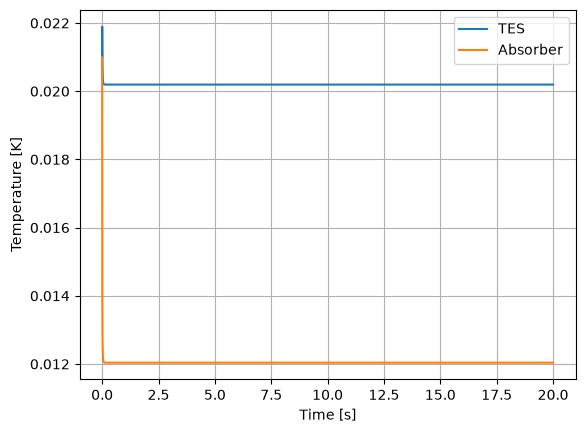

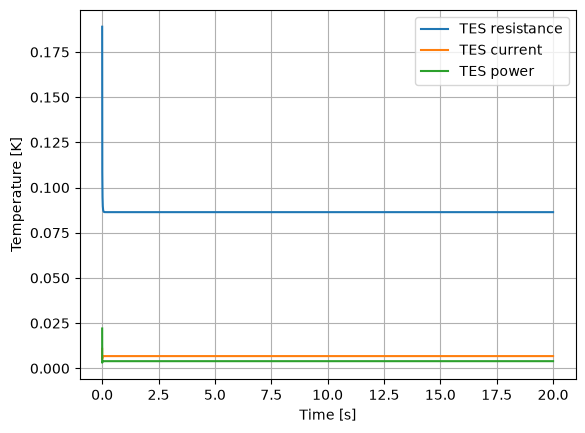

In [ ]:
# Plot all C and G to check if the system is at equilibrium
filename_init = f'../build/{MODEL_EXE_NAME}_res_init_v1.mat'
time_steps_init, data_init = pymodelica.load(filename_init)

plt.plot(time_steps_init, data_init['T1'], label="TES")
plt.plot(time_steps_init, data_init['T10'], label="Absorber")
plt.legend()
plt.xlabel("Time [s]")
plt.ylabel("Temperature [K]")
plt.grid()
plt.show()



plt.plot(time_steps_init, data_init['c1.R'], label="TES resistance")
plt.plot(time_steps_init, data_init['c1.i']*1000, label="TES current")

plt.plot(time_steps_init, data_init['c1.i']**2*data_init['c1.R'] *1e9, label="TES power")
plt.legend()
plt.xlabel("Time [s]")
plt.ylabel("Temperature [K]")
plt.grid()


In [ ]:
pymodelica.mod_svg("../System_LMO_v1.svg", "temp_image_v1.svg", data_init, system_name="System_LMO_v1", width=1200, display=True)

## Step 1b. Noise and Complex impedance

In [ ]:
model = pymodelica.TESModel(MODEL_FILE_LIN, 
                 MODEL_FILE, 
                 MODEL_RESULT,
                 config={"L": 0.3e-6, "RL": 0.02}, 
                 f_min = 1, f_max = 100e3, points = 1000)


noise_current, frequencies = model.get_noise(RL_temperature = 0.2,
    noise_electronics = 3.2e-12,
    noise_flicker_corner = 20,
    noise_flicker_gamma = 1,
    index_cinput = -1)

Resolution (Sigma) in eV =  1345.7360805710427


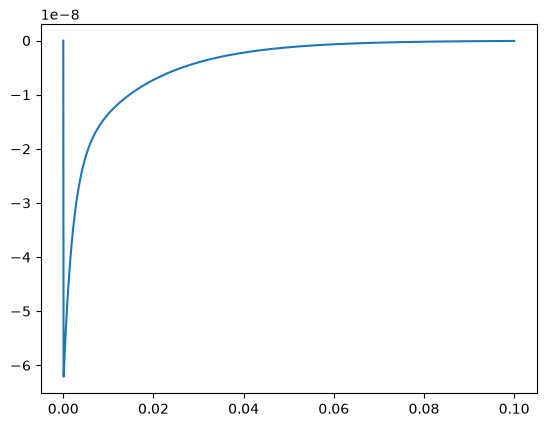

In [ ]:
t_linear, y_linear = model.get_impulse_split(index_cinput1 = 10, index_cinput2 = 2, 
                              fraction_1=config["Edep_fractiontarget"], 
                              scale_ev = config["Edep"], 
                              T=np.linspace(0,0.1,100_000))
plt.plot(t_linear, y_linear[:,1])

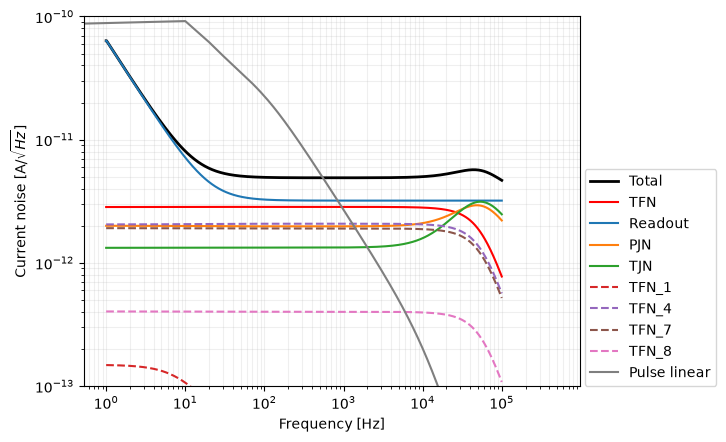

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: xlabel='Frequency [Hz]', ylabel='|$Z_{circ}$| [$\\Omega$]'>,
        <Axes: xlabel='Real($Z_{circ}$) [$\\Omega$]', ylabel='Imag($Z_{circ}$) [$\\Omega$]'>],
       dtype=object))

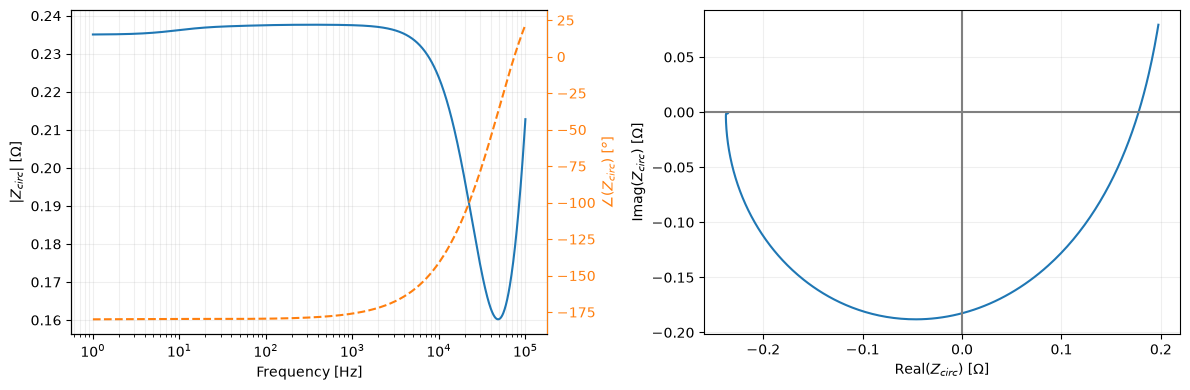

In [ ]:
model.plot_noise_current()

# Add pulse to the noise plot
fy, y_fft = scipy.signal.periodogram(y_linear[:, 1]*0.06, fs=1/(t_linear[1]-t_linear[0]))
plt.plot(fy, np.sqrt(y_fft), label="Pulse linear")
plt.legend(loc=(1.01,0))
plt.show()

model.plot_impedance()

# Step 2: impulse response

Compile another simulation with fine resolution starting from the final values of Step 1

In [ ]:

# Using -iif (Import Initial File) and -iit (Import Initial Time) to reset startTime = 0.0
log2 = subprocess.run(
    [
        f"./{MODEL_EXE_NAME}.exe",
        f"-r={MODEL_EXE_NAME}_res_final_v1.mat",
        f"-overrideFile={PARAMS}",
        "-s=dassl",
        "-w",
        "-startTime=0",
        "-stopTime=0.1",
        "-stepSize=1e-6",
        "-tolerance=1e-8",
        f"-iif={MODEL_EXE_NAME}_res_init_v1.mat",
        f"-iit={EQUILIBRIUM_TIME}",
        "-lv=-LOG_STDOUT",
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log2.stderr, log2.stdout

('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K16 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       

In [ ]:
filename = f'../build/{MODEL_EXE_NAME}_res_final_v1.mat'

time_steps, data = pymodelica.load(filename)
print(data.keys())

dict_keys(['CL.v', 'L.i', 'c1.T', 'c10.T', 'c11.T', 'c2.T', 'c3.T', 'c4.T', 'c5.T', 'c6.T', 'c7.T', 'c8.T', 'c9.T', 'der(CL.v)', 'der(L.i)', 'der(c1.T)', 'der(c10.T)', 'der(c11.T)', 'der(c2.T)', 'der(c3.T)', 'der(c4.T)', 'der(c5.T)', 'der(c6.T)', 'der(c7.T)', 'der(c8.T)', 'der(c9.T)', 'C1', 'C10', 'C11', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'CL.i', 'G1', 'G10', 'G11', 'G12', 'G13', 'G14', 'G15', 'G16', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'GND.p.i', 'GND.p.v', 'HeatSource.port.Q_flow', 'HeatSource1.port.Q_flow', 'L.v', 'RL.LossPower', 'RL.R_actual', 'RL.i', 'c1.P_Joule', 'c1.R', 'c1.cp', 'c1.heatPort.Q_flow', 'c1.v', 'c10.cp', 'c10.port.Q_flow', 'c11.cp', 'c11.port.Q_flow', 'c2.cp', 'c2.port.Q_flow', 'c3.cp', 'c3.port.Q_flow', 'c4.cp', 'c4.port.Q_flow', 'c5.cp', 'c5.port.Q_flow', 'c6.cp', 'c6.port.Q_flow', 'c7.cp', 'c7.port.Q_flow', 'c8.cp', 'c8.port.Q_flow', 'c9.cp', 'c9.port.Q_flow', 'edep_film.y', 'edep_target.y', 'fixedTemperature.port.Q_flow', 'g1.Q_flow', 'g

In [ ]:
data['K16'] 

array([6.13e-15, 6.13e-15])

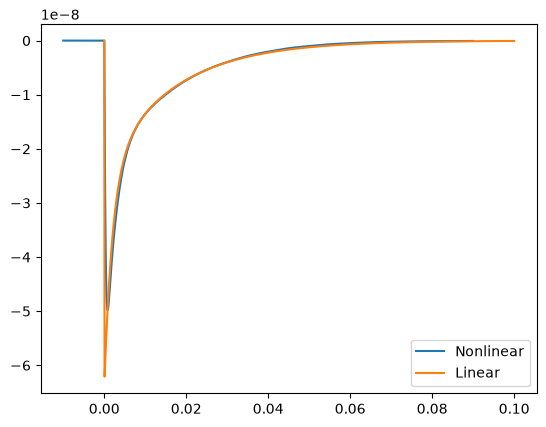

In [ ]:
y_nonlinear = data['c1.i'] - np.mean(data['c1.i'][:10])
plt.plot(time_steps-0.01, y_nonlinear, label="Nonlinear")
plt.plot(t_linear, y_linear[:,1], label="Linear")
plt.legend()

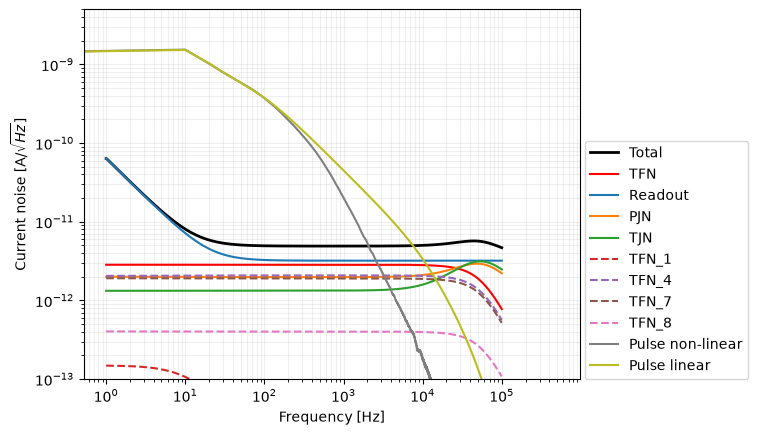

In [ ]:
model.plot_noise_current()

fy, y_fft = scipy.signal.periodogram(y_nonlinear, fs=1/(time_steps[1]-time_steps[0]))
plt.plot(fy, np.sqrt(y_fft), label="Pulse non-linear")

fy, y_fft = scipy.signal.periodogram( y_linear[:,1], fs=1/(t_linear[1]-t_linear[0]))
plt.plot(fy, np.sqrt(y_fft), label="Pulse linear")
plt.ylim(1e-13, 5e-9)
plt.legend(loc=(1.01,0))

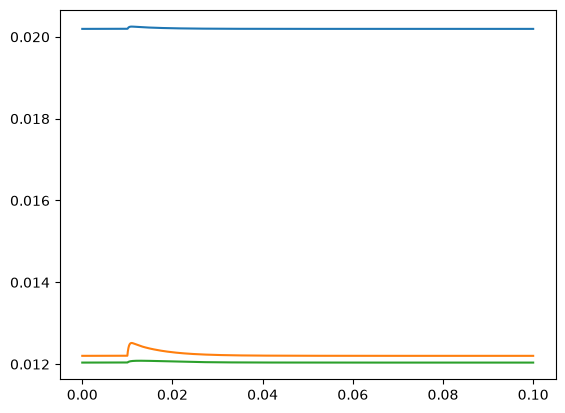

In [ ]:
plt.plot(time_steps, data['T1'])
plt.plot(time_steps, data['T2'])
plt.plot(time_steps, data['T10'])